# Pneumonia Detection CNN — Model Training Pipeline

 
This notebook builds, trains, and evaluates a Convolutional Neural Network (CNN) to classify chest X-ray images as **NORMAL** or **PNEUMONIA**. The model is trained on 32,540 preprocessed images stored in Amazon S3, using a tf.data pipeline.
 
---

In [ ]:
!pip install "sagemaker<3" boto3 --quiet

In [ ]:
!pip install pydicom opencv-python-headless awswrangler scikit-learn seaborn --quiet

In [9]:
# Imports

import tensorflow as tf
import keras
from keras import layers
import numpy as np
import pandas as pd
import boto3
import os
import io
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from io import BytesIO
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tqdm import tqdm
import awswrangler as wr

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.19.1


## Configuration
 
We use 128×128 grayscale images with a batch size of 16 to stay within the 16 GiB RAM limit of our `ml.t3.xlarge` SageMaker instance. The learning rate is set to 1e-3 with the Adam optimizer.

In [10]:
BUCKET_NAME = "pneumonia-data-set-group-4"
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-3
LOCAL_DIR = "/home/sagemaker-user/preprocessed-images"

s3 = boto3.client("s3")

## Load Metadata from S3
 
We read the image metadata CSV directly from S3. This file was created during the data preparation phase and contains each image's S3 key, label, source, and pixel statistics.

In [11]:
import io

obj = s3.get_object(Bucket=BUCKET_NAME, Key="pneumonia-project/metadata/image_metadata.csv")
df_meta = pd.read_csv(io.BytesIO(obj["Body"].read()))

df_meta = df_meta[~df_meta["preprocessed_s3_key"].str.contains(".ipynb_checkpoint", na=False)]

print(f"Total images: {len(df_meta)}")
print(df_meta["label"].value_counts())

Total images: 32540
label
NORMAL       22255
PNEUMONIA    10285
Name: count, dtype: int64


## Download Images to Local Disk
 
Reading 32,540 individual images from S3 during training is slow due to network latency on every request. We download all preprocessed images to the instance's local disk once, then read from disk during training. The `os.path.exists` check ensures we skip files already downloaded from previous runs.
 

In [12]:
LOCAL_DIR = "/home/sagemaker-user/preprocessed-images"
df_meta["local_path"] = df_meta["preprocessed_s3_key"].apply(
    lambda k: os.path.join(LOCAL_DIR, k.replace("/", "_"))
)

In [ ]:
os.makedirs(LOCAL_DIR, exist_ok=True)

print(f"Downloading {len(df_meta)} images to local disk...")
for _, row in tqdm(df_meta.iterrows(), total=len(df_meta)):
    key = row["preprocessed_s3_key"]
    local_path = os.path.join(LOCAL_DIR, key.replace("/", "_"))
    if not os.path.exists(local_path):
        s3.download_file(BUCKET_NAME, key, local_path)

df_meta["local_path"] = df_meta["preprocessed_s3_key"].apply(
    lambda k: os.path.join(LOCAL_DIR, k.replace("/", "_"))
)
print("Done!")

## Train / Val / Test / Production Split
 
We split the data into four sets using stratified sampling to preserve the NORMAL/PNEUMONIA ratio across all splits:
 
- **Training (40%)** — used to train the model
- **Validation (10%)** — used to monitor overfitting during training
- **Test (10%)** — used for final evaluation after training
- **Production (40%)** — reserved for future production inference

In [13]:
# Split — 40% train, 10% val, 10% test, 40% production

trainvaltest_df, prod_df = train_test_split(
    df_meta, test_size=0.40, random_state=42, stratify=df_meta["label_int"]
)
train_val_df, test_df = train_test_split(
    trainvaltest_df, test_size=1/6, random_state=42, stratify=trainvaltest_df["label_int"]
)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.20, random_state=42, stratify=train_val_df["label_int"]
)

print(f"Train:      {len(train_df)} ({len(train_df)/len(df_meta)*100:.1f}%)")
print(f"Val:        {len(val_df)} ({len(val_df)/len(df_meta)*100:.1f}%)")
print(f"Test:       {len(test_df)} ({len(test_df)/len(df_meta)*100:.1f}%)")
print(f"Production: {len(prod_df)} ({len(prod_df)/len(df_meta)*100:.1f}%)")

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df), ("Production", prod_df)]:
    counts = split["label"].value_counts()
    print(f"  {name:>10s} — NORMAL: {counts.get('NORMAL', 0)}, PNEUMONIA: {counts.get('PNEUMONIA', 0)}")

Train:      13016 (40.0%)
Val:        3254 (10.0%)
Test:       3254 (10.0%)
Production: 13016 (40.0%)
       Train — NORMAL: 8902, PNEUMONIA: 4114
         Val — NORMAL: 2225, PNEUMONIA: 1029
        Test — NORMAL: 2226, PNEUMONIA: 1028
  Production — NORMAL: 8902, PNEUMONIA: 4114


## Class Weights
 
Our dataset is imbalanced with roughly 2:1 NORMAL to PNEUMONIA ratio. Without class weights, the model biases toward the majority class. We compute inverse-frequency weights so the model is penalized more heavily for misclassifying the minority PNEUMONIA class.

In [14]:
# Class weights

n_normal = len(train_df[train_df["label_int"] == 0])
n_pneumonia = len(train_df[train_df["label_int"] == 1])
total = n_normal + n_pneumonia

class_weight = {
    0: total / (2.0 * n_normal),
    1: total / (2.0 * n_pneumonia),
}
print(f"Class weights: NORMAL={class_weight[0]:.4f}, PNEUMONIA={class_weight[1]:.4f}")

Class weights: NORMAL=0.7311, PNEUMONIA=1.5819


## tf.data Pipeline
 
We use native TensorFlow I/O operations (`tf.io.read_file`, `tf.io.decode_png`) instead of PIL/numpy to avoid memory leaks that occur with `tf.numpy_function`. The pipeline streams images in batches from local disk, applies data augmentation to the training set only, and prefetches the next batch while the current one is being processed.
 
**Data Augmentation** (training only): horizontal flips,  rotation,  zoom,  contrast, and  translation to increase effective dataset size and reduce overfitting.

In [15]:
# tf.data pipeline — reads from LOCAL disk (fast)

def load_sample(file_path, label):
    img_bytes = tf.io.read_file(file_path)
    img = tf.io.decode_png(img_bytes, channels=1)
    img = tf.image.resize(img, [128, 128])
    img = tf.cast(img, tf.float32)
    return img, label


augmentation_layer = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom((-0.1, 0.1)),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.05, 0.05),
], name="augmentation")


def apply_augmentation(image, label):
    image = augmentation_layer(image, training=True)
    return image, label


def make_dataset(df, shuffle=False, augment=False):
    paths = df["local_path"].values
    labels = df["label_int"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)

    ds = ds.map(load_sample, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(apply_augmentation, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


print("Building datasets...")
train_ds = make_dataset(train_df, shuffle=True, augment=True)
val_ds   = make_dataset(val_df,   shuffle=False, augment=False)
test_ds  = make_dataset(test_df,  shuffle=False, augment=False)

for images, labels in train_ds.take(1):
    print(f"Batch shape: {images.shape}")
    print(f"Pixel range: [{images.numpy().min():.1f}, {images.numpy().max():.1f}]")

Building datasets...


Batch shape: (16, 128, 128, 1)
Pixel range: [0.0, 255.0]


2026-06-14 18:45:54.049610: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Build CNN Model
 
A 4-block CNN architecture with increasing filter sizes (32 → 64 → 128 → 256). Each block uses two Conv2D layers with BatchNormalization and ReLU activation, followed by MaxPooling. A `Rescaling` layer normalizes pixel values from 0–255 to 0–1 inside the model. The classifier head uses GlobalAveragePooling, two Dense layers with Dropout for regularization, and a sigmoid output for binary classification.
 


In [ ]:
# Build CNN

def build_model():
    inputs = layers.Input(shape=(128, 128, 1), name="input_image")
    x = layers.Rescaling(1.0 / 255.0, name="rescaling")(inputs)

    # Block 1
    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    return keras.Model(inputs, outputs, name="pneumonia_cnn")

model = build_model()
model.summary()

Model: "pneumonia_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 1,257,825 (4.80 MB)

 Trainable params: 1,255,905 (4.79 MB)

 Non-trainable params: 1,920 (7.50 KB)

## Compile
 
We use the Adam optimizer with binary cross-entropy loss. Metrics include accuracy, precision, recall, and AUC to give a complete picture of model performance, especially important given the class imbalance.

In [11]:
# Compile

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)

## Train
 
Training uses three callbacks:
 
- **MemoryCleanup** — runs garbage collection after each epoch to prevent memory buildup
- **ModelCheckpoint** — saves the best model to disk after each epoch so progress is not lost if the kernel crashes
- **EarlyStopping** — stops training if validation loss does not improve for 5 consecutive epochs and restores the best weights
- **ReduceLROnPlateau** — halves the learning rate when validation loss plateaus for 3 epochs

In [ ]:
# Train

import gc

class MemoryCleanup(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

callbacks = [
    MemoryCleanup(),
    keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-6, verbose=1,
    ),
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight,
    callbacks=callbacks,
)

## Save Model to S3
 
We upload the best model checkpoint to our shared S3 bucket so it can be loaded later for inference without retraining.

In [4]:
import boto3
import shutil
import keras

BUCKET_NAME = "pneumonia-data-set-group-4"
s3 = boto3.client("s3")

# Upload the .keras file directly to S3
s3.upload_file("best_model.keras", BUCKET_NAME, "models/pneumonia_cnn_model.keras")
print(f"Saved to s3://{BUCKET_NAME}/models/pneumonia_cnn_model.keras")

2026-06-14 18:44:21.636657: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Saved to s3://pneumonia-data-set-group-4/models/pneumonia_cnn_model.keras


In [5]:
# Load Saved Model

model = keras.models.load_model("best_model.keras")
print("Model loaded!")
model.summary()

Model loaded!


Model: "pneumonia_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 3,769,637 (14.38 MB)

 Trainable params: 1,255,905 (4.79 MB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 2,511,812 (9.58 MB)

## Evaluation — Classification Report & Confusion Matrix
 
We evaluate on the held out test set (3,254 images) using a **0.4 classification threshold** instead of the default 0.5. The lower threshold prioritizes catching more pneumonia cases (higher recall) at the cost of slightly more false positives — a desirable tradeoff in medical diagnosis where missing a sick patient is worse than a false alarm.

In [ ]:
# Classification report and confusion matrix test set

y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.4).astype(int).flatten()

y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)



Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.88      0.83      0.85      2226
   PNEUMONIA       0.67      0.75      0.71      1028

    accuracy                           0.81      3254
   macro avg       0.78      0.79      0.78      3254
weighted avg       0.81      0.81      0.81      3254



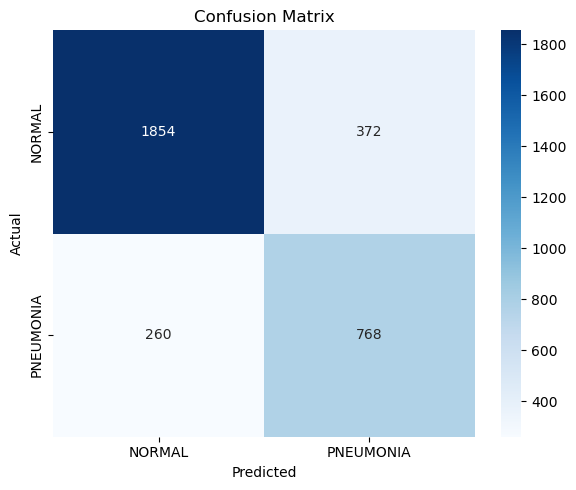

In [23]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Production Set Evaluation
 
The production set (40% of data, 13,016 images) was held out entirely from training, validation, and test evaluation. This simulates real-world deployment where the model encounters completely unseen data. While the test set was used to validate our training decisions (threshold tuning, model selection), the production set represents how the model would perform on new X-rays in a clinical setting.
 

In [ ]:
# Classification report and confusion matrix on Production test result
prod_ds = make_dataset(prod_df, shuffle=False, augment=False)

# Run predictions
prod_pred_probs = model.predict(prod_ds)
prod_pred = (prod_pred_probs > 0.4).astype(int).flatten()

prod_true = []
for _, labels in prod_ds:
    prod_true.extend(labels.numpy())
prod_true = np.array(prod_true)


Production Set Results:
              precision    recall  f1-score   support

      NORMAL       0.88      0.84      0.86      8902
   PNEUMONIA       0.68      0.74      0.71      4114

    accuracy                           0.81     13016
   macro avg       0.78      0.79      0.78     13016
weighted avg       0.81      0.81      0.81     13016



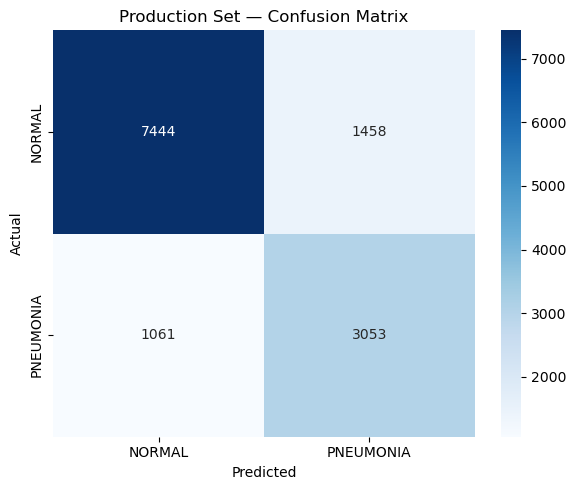

In [22]:
print("Production Set Results:")
print(classification_report(prod_true, prod_pred, target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(prod_true, prod_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Production Set — Confusion Matrix")
plt.tight_layout()
plt.show()